# 1. Dataset Overview

The RSNA Pneumonia Detection Challenge dataset contains chest X-ray images in DICOM format along with bounding-box annotations for pneumonia-positive cases.


In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
details = pd.read_csv("C:\\Users\\Lucky\\Downloads\\archive\\drive-download-20240112T131344Z-002\\stage_2_detailed_class_info.csv")
labels = pd.read_csv("C:\\Users\\Lucky\\Downloads\\archive\\drive-download-20240112T131344Z-002\\stage_2_train_labels.csv")

In [16]:
labels.head()

,patientId,x,y,width,height,Target
0,0004cfab-14fd-4e49-80ba-63a80b6bddd6,NaN,NaN,NaN,NaN,0
1,00313ee0-9eaa-42f4-b0ab-c148ed3241cd,NaN,NaN,NaN,NaN,0
2,00322d4d-1c29-4943-afc9-b6754be640eb,NaN,NaN,NaN,NaN,0
3,003d8fa0-6bf1-40ed-b54c-ac657f8495c5,NaN,NaN,NaN,NaN,0
4,00436515-870c-4b36-a041-de91049b9ab4,264.0,152.0,213.0,379.0,1


In [11]:
print(labels.info())
print(details.info())

<class 'pandas.DataFrame'>
RangeIndex: 30227 entries, 0 to 30226
Data columns (total 6 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   patientId  30227 non-null  str    
 1   x          9555 non-null   float64
 2   y          9555 non-null   float64
 3   width      9555 non-null   float64
 4   height     9555 non-null   float64
 5   Target     30227 non-null  int64  
dtypes: float64(4), int64(1), str(1)
memory usage: 1.4 MB
None
<class 'pandas.DataFrame'>
RangeIndex: 30227 entries, 0 to 30226
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   patientId  30227 non-null  str  
 1   class      30227 non-null  str  
dtypes: str(2)
memory usage: 472.4 KB
None


In [12]:
print(labels.shape)
print(details.shape)

(30227, 6)
(30227, 2)


In [15]:
labels.isnull().sum()

patientId        0
x            20672
y            20672
width        20672
height       20672
Target           0
dtype: int64

<BarContainer object of 2 artists>

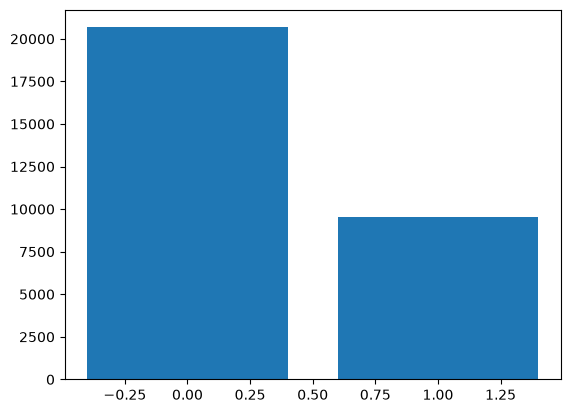

In [26]:
plt.bar(height = labels["Target"].value_counts(), x= labels["Target"].value_counts().index)

In [17]:
details["class"].value_counts()

class
No Lung Opacity / Not Normal    11821
Lung Opacity                     9555
Normal                           8851
Name: count, dtype: int64

In [27]:
merged = labels.merge(details, on="patientId")

In [30]:
import pydicom

image = pydicom.dcmread("C:\\Users\\Lucky\\Downloads\\archive\\drive-download-20240112T131344Z-002\\stage_2_train_images\\000924cf-0f8d-42bd-9158-1af53881a557.dcm")

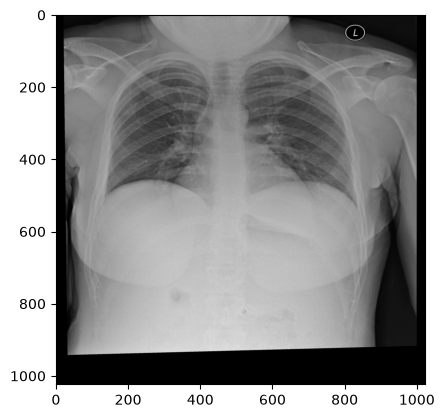

In [31]:
plt.imshow(image.pixel_array, cmap="gray")

In [33]:
print(image.pixel_array.shape)

print(image.pixel_array.dtype)

print(image.pixel_array.min())

print(image.pixel_array.max())

(1024, 1024)
uint8
0
255


In [ ]:
import os
import glob
import pydicom
import numpy as np
from PIL import Image

# Configure input/output directories (change as needed)
input_dir = r"C:/Users/Lucky/Downloads/archive/drive-download-20240112T131344Z-002/stage_2_train_images"
output_dir = "png_images"
os.makedirs(output_dir, exist_ok=True)

# Find all .dcm files
dicom_files = glob.glob(os.path.join(input_dir, "*.dcm"))
print(f"Found {len(dicom_files)} DICOM files")

for fp in dicom_files:
    try:
        ds = pydicom.dcmread(fp)
        arr = ds.pixel_array.astype(np.float32)
        # Handle MONOCHROME1 (inverted) photometric interpretation
        if getattr(ds, 'PhotometricInterpretation', '').upper() == 'MONOCHROME1':
            arr = arr.max() - arr
        # Normalize to 0-255
        arr = arr - arr.min()
        if arr.max() != 0:
            arr = arr / arr.max()
        arr = (arr * 255).astype(np.uint8)
        im = Image.fromarray(arr)
        out_name = os.path.splitext(os.path.basename(fp))[0] + ".png"
        out_path = os.path.join(output_dir, out_name)
        im.save(out_path)
        print(f"Saved: {out_path}")
    except Exception as e:
        print(f"Failed {fp}: {e}")
